# match the chl dataset with id tags to the OWT data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker,colors
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy import stats
import math
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime,date, timedelta
import datetime as dt 
import cmocean as cmoc
import cmocean.cm as cmo
from erddapy import ERDDAP
import time
import requests
from scipy import stats, odr
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import re
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import ast
import matplotlib.gridspec as gridspec


In [2]:
def haversine_distance_vectorized(lat1, lon1, lat2, lon2):
    """
    Calculate the haversine distance between two sets of points in a vectorized way.
    
    Parameters:
        lat1, lon1: Latitude and longitude of the first set of points (arrays).
        lat2, lon2: Latitude and longitude of the second set of points (arrays).
    
    Returns:
        Array of distances in kilometers.
    """
    R = 6371  # Earth radius in kilometers
    
    # Convert latitude and longitude from degrees to radians
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    # Calculate differences in coordinates
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    # Apply haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    
    return distance

In [3]:
#insitu_year
#create list of just datetimes per year
#create a def that will take a dataframe and year number and return list of all unique datetimes
def insitu_year(df,year):
    ''' 
    Takes a dataframe and given year, returns dataframe with only data from that year and list of YYYmmdd times
    df = in situ dataframe, with datetime column
    year = desired year
    returns:
    filtered_df= in situ dataframe with only that year 
    dates = list of unique dates in format YYYYmmdd
    '''
    year = str(year) #ensure year is string
    start_date = pd.Timestamp(year+'-01-01 00:00:00') #jan 1st of year
    end_date = pd.Timestamp(year+'-12-31 23:59:59') #dec 31st of year
    filtered_df = df[df['datetime'].between(start_date,end_date)] #only pull between these dates from df
    unique_dates=filtered_df.copy()
    unique_dates['date'] = unique_dates.datetime.dt.date #create column of just date
    unique_dates = unique_dates.drop_duplicates(subset=['date'], keep='first').astype(str) #find all unique dates and turn to str
    unique_dates['date'] = unique_dates['date'].str.replace('-', '') #take out all - 
    dates = unique_dates.date
    return filtered_df, dates


In [4]:
#sat_insit_match
#making the matching data code a function
def sat_insit_match3(sat_xr, insit_df, spatial_diff_km,variable):
    ''' takes a satellite xarray and a in situ dataframe and finds datapoinst with same lat/lon/datetime withing bounds
        sat_xr: satellite xarray with variable as same name as matching variable.
            must have same dates as insit_df, use insitu_year
        insit_df: in situ dataframe with variable as same name as matching variable
        spatial_diff_km: spatial boundary for matching in km
        var: variable name to match
        return: insitu dataframe with additional colum for satellite matches 
    '''
    #fixing it up to be less unweildly 
    insit_df['datetime'] = pd.to_datetime(insit_df['datetime'], errors='coerce')
    insit_df.dropna(subset=['datetime'], inplace=True)
    insit_df.dropna(subset=['lat'], inplace=True) # Also drop NaN in lat, as it's critical for matching
    insit_df.reset_index(inplace=True, drop=True)
    
     # --- Step 2: Vectorized Nearest-Neighbor Search ---
    # Create xarray DataArrays from the in-situ coordinates to use as indexers.
    time_indexer = xr.DataArray(insit_df['datetime'], dims='point')
    lat_indexer = xr.DataArray(insit_df['lat'], dims='point')
    lon_indexer = xr.DataArray(insit_df['lon'], dims='point')

    print("Finding nearest satellite points for all in-situ data at once...")
    # Perform the selection for all points in a single, fast operation.
    matched_sat_points = sat_xr.sel(
        time=time_indexer,
        latitude=lat_indexer,longitude=lon_indexer,
        method='nearest')

    # --- Step 3: Vectorized Filtering ---
    print("Filtering matches based on spatial and temporal criteria...")
    # Calculate spatial distance for all points vectorially.
    distances_km = haversine_distance_vectorized(
        insit_df['lat'].values,
        insit_df['lon'].values,
        matched_sat_points['latitude'].values,
        matched_sat_points['longitude'].values)

    # Create boolean masks to identify valid matches.
    # 1. Check if the match is on the exact same day.
    time_match_mask = insit_df['datetime'].dt.date.values == pd.to_datetime(matched_sat_points['time'].values).date
    
    # 2. Check if the match is within the spatial distance limit.
    spatial_match_mask = distances_km <= spatial_diff_km

    # 3. Combine masks to find all valid matches.
    valid_match_mask = time_match_mask & spatial_match_mask

    # --- Step 4: Extract 3x3 Grid and Finalize Data ---
    # Initialize result columns in the DataFrame.
    insit_df['owt'] = np.nan
    #insit_df['matched_sat_time'] = pd.NaT
    insit_df['all_classes'] = np.nan
    insit_df['all_classes'] = insit_df['all_classes'].astype(object)
    #insit_df['matched_spatial_dist_km'] = np.nan

    # Get the indices of only the valid matches.
    valid_indices = np.where(valid_match_mask)[0]
    print(f"Found {len(valid_indices)} valid matches out of {len(insit_df)} points. Now extracting 3x3 grids...")
    
    if len(valid_indices) > 0:
        # For performance, get coordinate arrays once before the loop.
        sat_lat_coords = sat_xr['latitude'].values
        sat_lon_coords = sat_xr['longitude'].values

        # Loop ONLY over the valid matches to extract the 3x3 grid.
        for idx in valid_indices:
            # Get the coordinates of the valid matched satellite point.
            matched_lat = matched_sat_points['latitude'].values[idx]
            matched_lon = matched_sat_points['longitude'].values[idx]
            matched_time = matched_sat_points['time'].values[idx]

            # Find the integer index using the fast 'get_loc' method.
            lat_idx = sat_xr.indexes['latitude'].get_loc(matched_lat)
            lon_idx = sat_xr.indexes['longitude'].get_loc(matched_lon)
            time_idx = sat_xr.indexes['time'].get_loc(matched_time)

            # Define the 3x3 window boundaries.
            lat_slice = slice(max(0, lat_idx - 1), min(len(sat_lat_coords), lat_idx + 2))
            lon_slice = slice(max(0, lon_idx - 1), min(len(sat_lon_coords), lon_idx + 2))
            
            # Extract the 3x3 grid using integer-based selection (isel).
            grid_data = sat_xr[variable].isel(time=time_idx, latitude=lat_slice, longitude=lon_slice)
            grid_values = grid_data.values.flatten()
            
            # Calculate the mode, ignoring NaN values.
            valid_grid_values = grid_values[~np.isnan(grid_values)]
            grid_mode = stats.mode(valid_grid_values).mode if valid_grid_values.size > 0 else np.nan

            # Store the results in the DataFrame.
            insit_df.loc[idx, 'owt'] = grid_mode
            insit_df.at[idx, 'all_classes'] = grid_values.tolist()
            #insit_df.loc[idx, 'matched_sat_time'] = matched_time
           # insit_df.loc[idx, 'matched_spatial_dist_km'] = distances_km[idx]

    print('Finished matching process!')
    return insit_df

In [5]:
def slice_before_concat(ds):
        """
        Slices the dataset to keep only a specific lat/lon range.
        """
        # Example: Slice the 'time' dimension to keep only data after a certain date
        ds = ds.sel(latitude=slice(80,10),longitude=slice(-179,-40))
        return ds

In [6]:
#def loop that does all of the below
#I want to make it so that you enter insitu df, satellite folder, spatial and temporal resolution, and variable, and year
#Then it loops through existing files, then checks for good_datasets
#Then combines into 1 dataset and reduces lat/lon dimensions
#Then it matches the data 
def owt_insit_match(insitu_df, sat_xr, spatial_res, variable, year):
    '''
    code that produces dataframe of matching satellite points and insitu points.
    input: 
        insitu_df: dataframe with datetime, lat, lon, and variable
        sat_xr: folder string to satellite data
        spatial_res: resolution boundry for matching (km)
        variable: the variable being matched (chl)
        year: the year in situ and sat data are being compared (int)
    returns:
        satellite xarray of coastlat us, only that year
        matched chlorophyll + variable dataframe, where var_new is the OWT matched datapoints
    '''
    #first, reduce insitu_df to onl the year desired
    insit_year, dates_year= insitu_year(insitu_df,year)
    #next, pull satellite folder names
    #loop through dates and if the sat data exists and matches date, append to list of file paths.
    
    #existing_files= []
    #for date in sorted(dates_year):
    #    file_date = str(sat_xr)+str(date)+'-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc'
    #    if os.path.exists(file_date):
    #        existing_files.append(file_date)
    #    else:
    #        print(f"Warning: File not found for date {date}: {file_date}")
            
            #uncomment below if you're getting errors about corrupted files
    existing_files= []
    var = 'water_class'
    for date in sorted(dates_year):
        file_date = str(sat_xr)+str(date)+'-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc'
        #files.append(file_date)
        if os.path.exists(file_date): #if path exists, try to open it
            try:
                temp_ds = xr.open_dataset(file_date, chunks={}) # Use chunks={} for Dask if needed
                _ = temp_ds[var].isel(time=0, latitude=0, longitude=0).compute()
                temp_ds.close()
                existing_files.append(file_date)
            except Exception as e:
                print(f"Skipping corrupted or unreadable file: {file_date}") #. Error: {e}
                #temp_ds.close()
        else:
             print(f"Warning: File not found for date {date}: {file_date}")
    #concat all satellite .nc files into 1        
    #ds_combined = xr.open_mfdataset(existing_files, combine='by_coords')
    #coastal_us_combo = ds_combined.sel(latitude=slice(75,10),longitude=slice(-179,-60)) 
    coastal_us_combo= xr.open_mfdataset(existing_files, preprocess=slice_before_concat,combine='by_coords')
    print('satellite refiguring complete')
    test_insitu = insit_year.copy()
    #ds_renamed = coastal_us_combo.rename({"water_class":variable})
    matched_chl = sat_insit_match3(coastal_us_combo, test_insitu, spatial_res,variable)
    return matched_chl  #coastal_us_combo, for now just return matched dataframe for space


In [7]:
#load in all the data with the sattellite matchups 
chl_all = pd.read_excel(r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\sat_matchupCHL2.xlsx")
chl_all['datetime'] = pd.to_datetime(chl_all['datetime'],format='mixed') 

In [8]:
#all reducing already done in first round of matchups 
insit_chl_coast2 = chl_all.copy()
test= insit_chl_coast2['datetime'].dt.year
test.value_counts()

datetime
2006    6741
2024    5390
2025    5068
2007    4940
2019    4371
2022    4209
2023    4193
2020    3221
2018    3204
2021    3104
2005    2917
2017    2770
2016    2503
2008    1889
2015    1869
2011    1746
2010    1593
2012    1578
2013    1543
2009    1503
2014    1325
2004    1294
2002    1144
2003    1044
2001    1038
2000     743
Name: count, dtype: int64

In [11]:
%%time
df_matched2000 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2000)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 723 valid matches out of 743 points. Now extracting 3x3 grids...
Finished matching process!
CPU times: total: 25.2 s
Wall time: 1h 29min 24s


In [19]:
df_matched2001 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2001)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1032 valid matches out of 1038 points. Now extracting 3x3 grids...
Finished matching process!


In [20]:
df_matched2002 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2002)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 778 valid matches out of 1144 points. Now extracting 3x3 grids...
Finished matching process!


In [21]:
df_matched2003 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2003)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 976 valid matches out of 1044 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2004 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2004)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1285 valid matches out of 1294 points. Now extracting 3x3 grids...
Finished matching process!


In [11]:
df_matched2005 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2005)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2912 valid matches out of 2917 points. Now extracting 3x3 grids...
Finished matching process!


In [12]:
df_matched2006 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2006)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 6739 valid matches out of 6741 points. Now extracting 3x3 grids...
Finished matching process!


In [28]:
df_matched2007 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2007)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4930 valid matches out of 4940 points. Now extracting 3x3 grids...
Finished matching process!


In [30]:
df_matched2008 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2008)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1881 valid matches out of 1889 points. Now extracting 3x3 grids...
Finished matching process!


In [31]:
df_matched2009 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2009)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1498 valid matches out of 1503 points. Now extracting 3x3 grids...
Finished matching process!


In [36]:
df_matched2010 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2010)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1577 valid matches out of 1593 points. Now extracting 3x3 grids...
Finished matching process!


In [38]:
df_matched2011 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2011)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1746 valid matches out of 1746 points. Now extracting 3x3 grids...
Finished matching process!


In [39]:
df_matched2012 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2012)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1577 valid matches out of 1578 points. Now extracting 3x3 grids...
Finished matching process!


In [41]:
df_matched2013 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2013)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1543 valid matches out of 1543 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
df_matched2014 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2014)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1325 valid matches out of 1325 points. Now extracting 3x3 grids...
Finished matching process!


In [12]:
df_matched2015 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2015)

Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150312-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150317-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150318-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150319-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150325-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150327-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_20150328-OCCCI-V6.0-GLOBAL_MAPPED-OWC_WEI.nc
Skipping corrupted or unreadable file: J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY

In [13]:
df_matched2016 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2016)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2497 valid matches out of 2503 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2017 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2017)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2752 valid matches out of 2770 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2018 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2018)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 3151 valid matches out of 3204 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2019 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2019)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4247 valid matches out of 4371 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
df_matched2020 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2020)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 2922 valid matches out of 3221 points. Now extracting 3x3 grids...
Finished matching process!


In [11]:
df_matched2021 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2021)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 3046 valid matches out of 3104 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
df_matched2022 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2022)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4193 valid matches out of 4209 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2023 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2023)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 4090 valid matches out of 4193 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2024 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2024)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 5167 valid matches out of 5390 points. Now extracting 3x3 grids...
Finished matching process!


In [9]:
df_matched2025 = owt_insit_match(insit_chl_coast2, r'J:\OCCCI\V6.0\SOURCE\GLOBAL_4KM_DAILY\OWC_WEI\D_',6, 'water_class', 2025)

satellite refiguring complete
Finding nearest satellite points for all in-situ data at once...
Filtering matches based on spatial and temporal criteria...
Found 1376 valid matches out of 5068 points. Now extracting 3x3 grids...
Finished matching process!


In [10]:
current_matchup = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\owt_allchlV3.xlsx')

In [11]:
dfs=[current_matchup,df_matched2023] 
matched_all = pd.concat(dfs).reset_index(drop=True)

In [13]:
matched_all.to_excel("owt_allchlV3.xlsx", index = False)

In [12]:
test= matched_all['datetime'].dt.year
test.value_counts()

datetime
2006    6741
2024    5390
2025    5068
2007    4940
2019    4371
2022    4209
2023    4193
2020    3221
2018    3204
2021    3104
2005    2917
2017    2770
2016    2503
2008    1889
2015    1869
2011    1746
2010    1593
2012    1578
2013    1543
2009    1503
2014    1325
2004    1294
2002    1144
2003    1044
2001    1038
2000     743
Name: count, dtype: int64

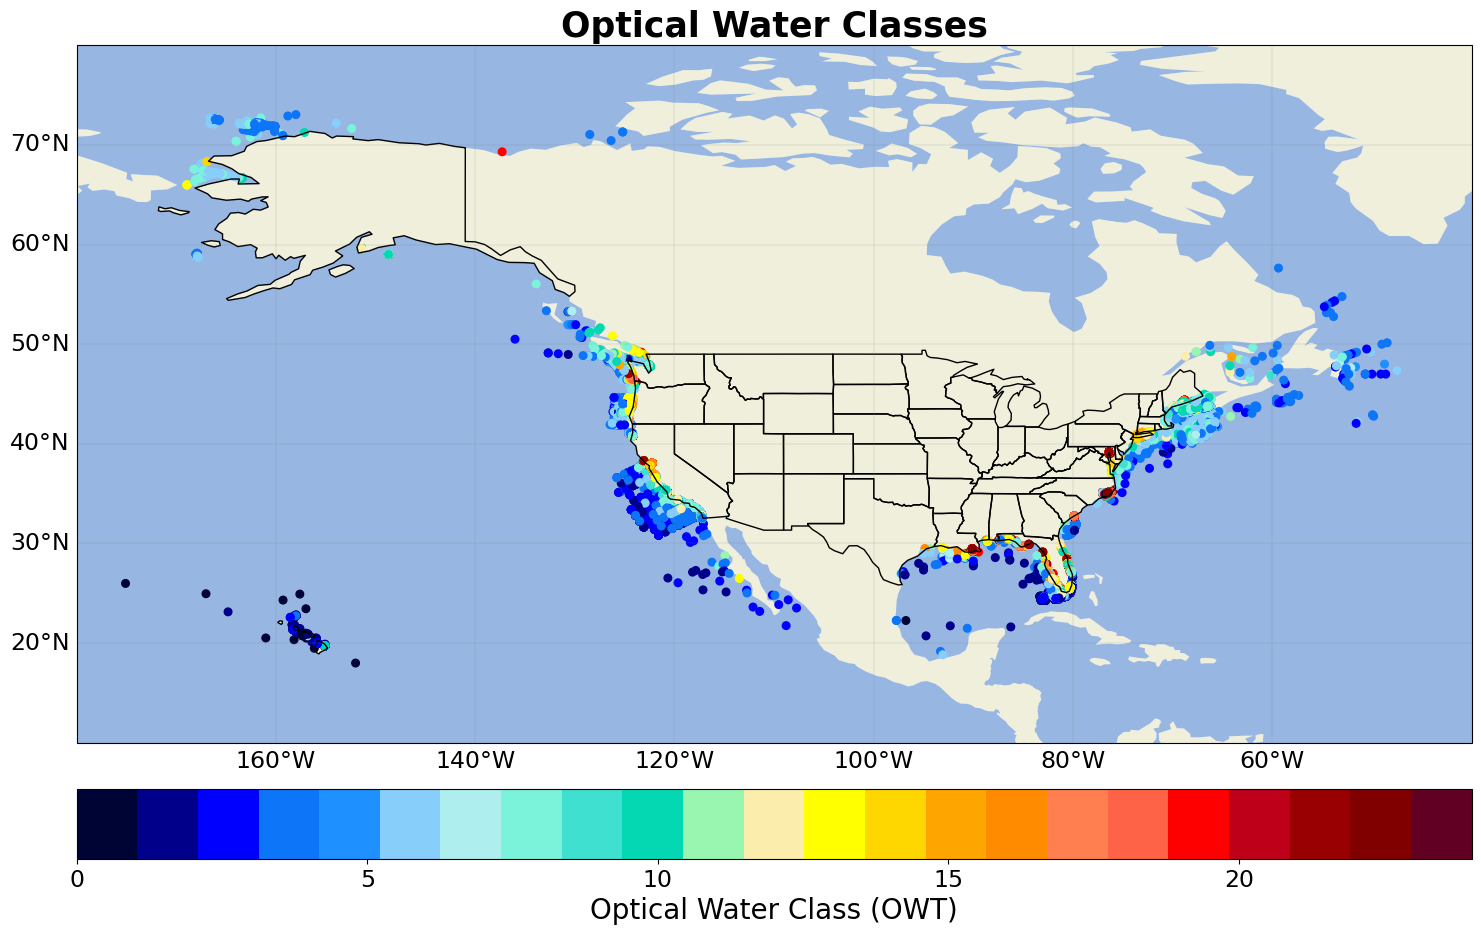

In [18]:
colors = ['xkcd:dark navy','darkblue','blue','xkcd:deep sky blue','dodgerblue','lightskyblue','paleturquoise', 'xkcd:tiffany blue','turquoise','xkcd:aquamarine', 
          'xkcd:light sea green','xkcd:light tan',
          'yellow','gold','orange','darkorange','coral','tomato','red','xkcd:scarlet','xkcd:blood red','maroon','xkcd:burgundy']
color_bar_custom = mcolors.ListedColormap(colors)

fig, axs1= plt.subplots(subplot_kw={'projection': cartopy.crs.PlateCarree()},figsize=(18, 12) )
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.STATES)
im=axs1.scatter(current_owt.lon,current_owt.lat,c=current_owt.owt,cmap=color_bar_custom,s=30, vmin=0, vmax=24)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style = {'size': 17, 'color': 'k'}
gl.ylabel_style = {'size': 17, 'color': 'k'}
cb=fig.colorbar(im,ax=axs1,orientation='horizontal',pad=0.05)
axs1.set_title('Optical Water Classes', fontsize=25, fontweight='bold')
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
cb.set_label('Optical Water Class (OWT)',fontsize=20)
cb.ax.tick_params(labelsize=17) # Adjust '14' to your desired font size
axs1.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
